# Melt


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/ny_county_pop.csv")

df

,county,gender,child,adult,senior
0,Albany County,M,29296,99324,24568
1,Albany County,F,28137,102485,31564
2,Allegany County,M,4803,14536,4526
3,Allegany County,F,4541,13868,4753
4,Bronx County,M,177091,414274,79363
...,...,...,...,...,...
119,Westchester County,F,104119,306495,100289
120,Wyoming County,M,3667,13857,3905
121,Wyoming County,F,3810,10710,4031
122,Yates County,M,2810,6658,2616


## Basic melting

Goal: make this dataframe a long table, in other words, having one column with values instead of three.

- `id_vars`: columns to keep fixed
- Everything else becomes long format
- `df.melt` is equivalent to `pd.melt(df)`

Note:
- If you don't set the value for `var_name`, it will be set as `variable`
- If you don't set the value for `value_name`, it will be set as `value`

In [44]:
melt_df = df.melt(id_vars=["county", "gender"],
                  value_vars=['child', 'adult', 'senior'],
                  var_name="age_group", value_name='population')

melt_df

,county,gender,age_group,population
0,Albany County,M,child,29296
1,Albany County,F,child,28137
2,Allegany County,M,child,4803
3,Allegany County,F,child,4541
4,Bronx County,M,child,177091
...,...,...,...,...
367,Westchester County,F,senior,100289
368,Wyoming County,M,senior,3905
369,Wyoming County,F,senior,4031
370,Yates County,M,senior,2616


In [45]:
# above cell is equivalent to

melt_df = pd.melt(
    frame=df,
    id_vars=["county", "gender"],
    value_vars=['child', 'adult', 'senior'],
    var_name="age_group", value_name='population')

melt_df.head()

,county,gender,age_group,population
0,Albany County,M,child,29296
1,Albany County,F,child,28137
2,Allegany County,M,child,4803
3,Allegany County,F,child,4541
4,Bronx County,M,child,177091


### Melted long tables are good for grouping and plotting

Let's say we wanted to plot box plots by age groups of counties in the NY state, separating by gender

#### Plotting using the original dataset
We need to plot one by one


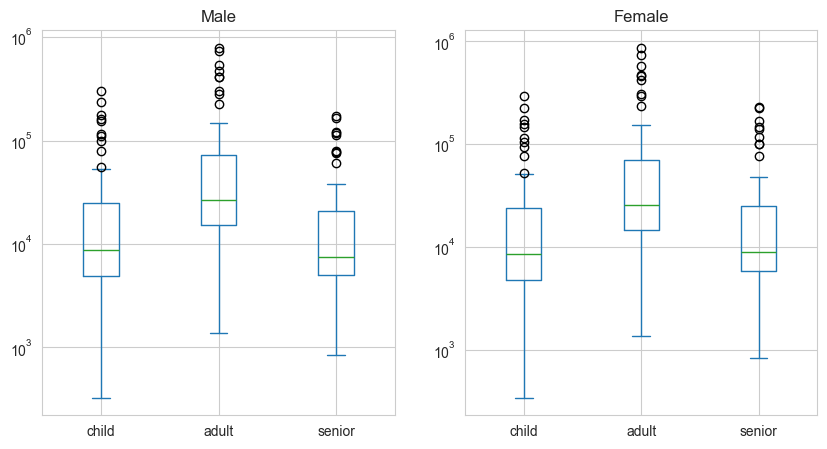

In [88]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

df[df['gender']=='M'].plot(kind='box', ax=axes.flat[0], logy=True)
df[df['gender']=='F'].plot(kind='box', ax=axes.flat[1], logy=True)

axes.flat[0].title.set_text("Male")
axes.flat[1].title.set_text("Female")

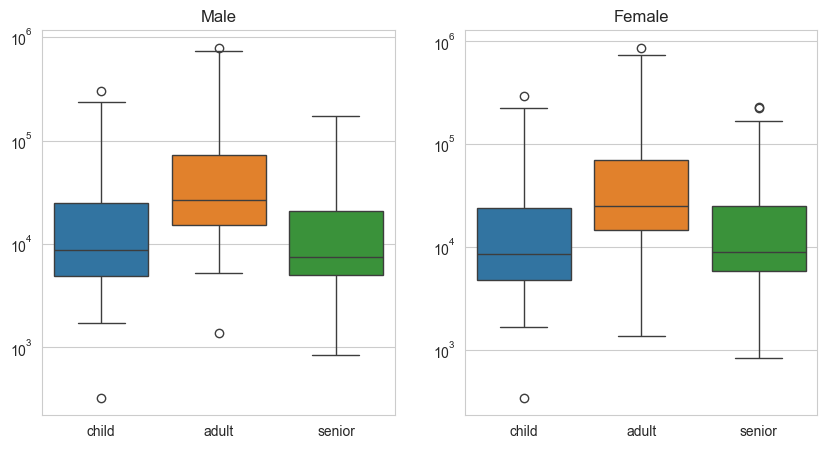

In [90]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.boxplot(data=df[df['gender']=='M'], ax=axes.flat[0], log_scale=True)
sns.boxplot(data=df[df['gender']=='F'], ax=axes.flat[1], log_scale=True)

axes.flat[0].title.set_text("Male")
axes.flat[1].title.set_text("Female")

#### Plotting using the melt dataset
Only one line is needed

<Axes: xlabel='age_group', ylabel='population'>

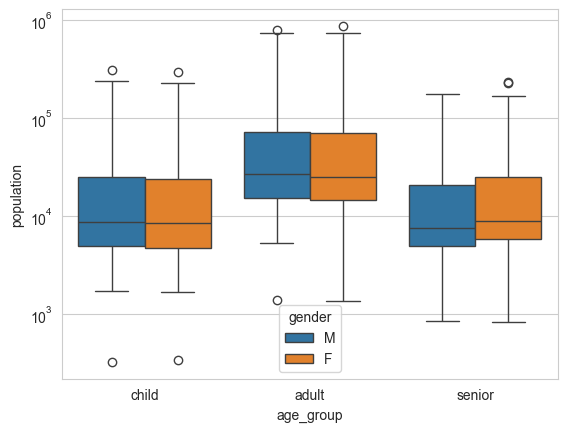

In [91]:
sns.boxplot(data=melt_df, x='age_group', y='population', hue='gender', log_scale=True)

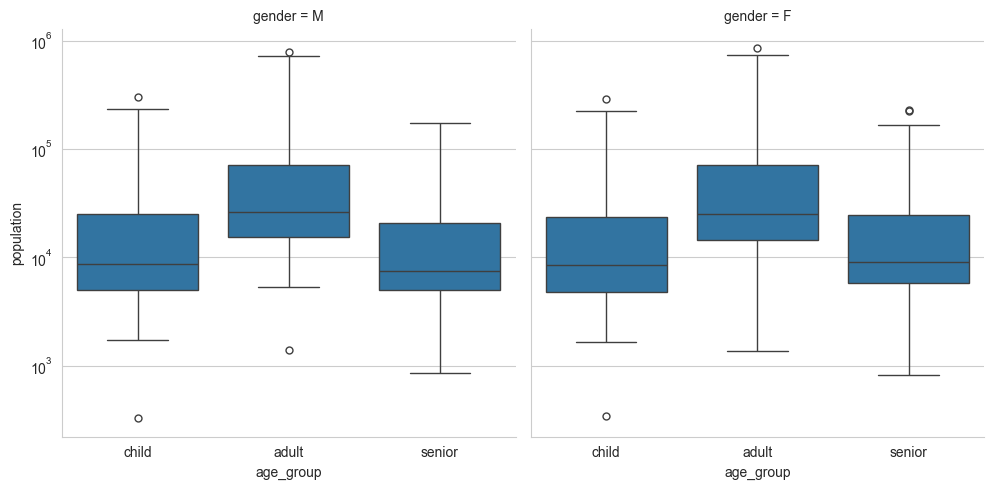

In [87]:
sns.catplot(kind='box', data=melt_df, x='age_group', y='population', col='gender', log_scale=True)

## Melt + groupby

if we don't care about gender, and we only wanted to know the population in each of the three age groups regardless of gender, we can combine (chain) melt with groupby
### Melt -> groupby

In [11]:
melt_df=df.melt(id_vars='county',
                  value_vars=['child', 'adult', 'senior'],
                  var_name="age_group", value_name='population').groupby(["county",'age_group'])['population'].sum().reset_index()
melt_df

,county,age_group,population
0,Albany County,adult,201809
1,Albany County,child,57433
2,Albany County,senior,56132
3,Allegany County,adult,28404
4,Allegany County,child,9344
...,...,...,...
181,Wyoming County,child,7477
182,Wyoming County,senior,7936
183,Yates County,adult,13619
184,Yates County,child,5626


### groupby -> melt

In [21]:
df.groupby('county',as_index=False).sum().melt(id_vars='county',
                  value_vars=['child', 'adult', 'senior'],
                  var_name="age_group", value_name='population', ignore_index=True).sort_values('county', ascending=True, ignore_index=True)


,county,age_group,population
0,Albany County,child,57433
1,Albany County,adult,201809
2,Albany County,senior,56132
3,Allegany County,child,9344
4,Allegany County,adult,28404
...,...,...,...
181,Wyoming County,child,7477
182,Wyoming County,adult,24567
183,Yates County,adult,13619
184,Yates County,child,5626


## Pivot <-> melt back

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32

df[['month','day','temp_F']]

,month,day,temp_F
0,1,1,45.50
1,1,2,37.94
2,1,3,33.08
3,1,4,29.30
4,1,5,27.86
...,...,...,...
360,12,27,26.06
361,12,28,26.96
362,12,29,42.44
363,12,30,29.84


### Pivot

In [24]:
pivot = df.pivot(index="day", columns="month", values="temp_F")
pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,45.50,35.06,43.88,47.48,59.18,54.86,76.82,64.22,66.20,60.80,51.08,39.02
2,37.94,21.20,24.08,39.56,63.14,59.54,73.58,69.08,66.56,57.74,49.28,37.58
3,33.08,37.04,23.72,49.64,65.66,65.48,75.56,71.42,66.02,60.08,54.50,34.34
4,29.30,38.84,36.86,62.78,62.42,68.54,69.98,73.76,67.82,65.84,51.44,35.60
5,27.86,27.14,48.02,49.46,59.72,73.58,73.94,74.66,71.60,72.14,54.68,24.08
6,27.86,31.28,48.56,43.70,59.90,73.40,75.38,70.52,72.68,68.54,50.54,36.68
7,22.64,36.50,36.50,42.26,61.88,69.80,76.10,70.52,61.52,67.82,47.84,37.94
8,23.90,28.76,38.66,38.30,66.20,65.30,79.34,70.16,62.78,65.48,57.38,29.84
9,24.62,29.66,37.22,34.52,57.56,60.08,77.36,70.70,64.22,54.68,56.84,23.90


### Melt back

In [37]:
pivot_reset = pivot.reset_index()

df_long = pd.melt(
    pivot_reset,
    id_vars="day",
    var_name="month",
    value_name="temp_F",
).dropna(ignore_index=True)[['month','day','temp_F']]

df_long

,month,day,temp_F
0,1,1,45.50
1,1,2,37.94
2,1,3,33.08
3,1,4,29.30
4,1,5,27.86
...,...,...,...
360,12,27,26.06
361,12,28,26.96
362,12,29,42.44
363,12,30,29.84
